<a href="https://colab.research.google.com/github/benchcodes/COM242_CCMACLRL/blob/main/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

data = {
    "name": [
        "Bench", "Matthew", "Jhon", "Roy", "Nat",
        "Sophia", "Lucas", "Mia", "Mason", "Charlotte",
        "Logan", "Amelia", "Elijah", "Harper", "Aiden"
    ],

    "Followers": [
        95, 350, 40, 620, 30,
        490, 70, 730, 120, 410,
        60, 280, 150, 520, 35
    ],

    "friends": [
        40, 180, 25, 360, 18,
        310, 35, 430, 70, 240,
        28, 170, 85, 320, 20
    ],

    # 0 = Introvert, 1 = Extrovert
    "Personality": [
        0, 1, 0, 1, 0,
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

In [21]:
df.head()

,name,Followers,friends,Personality
0,Bench,95,40,0
1,Matthew,350,180,1
2,Jhon,40,25,0
3,Roy,620,360,1
4,Nat,30,18,0


Display the summary of all the features of the dataset using `.info()`

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   name         15 non-null     object
 1   Followers    15 non-null     int64 
 2   friends      15 non-null     int64 
 3   Personality  15 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 612.0+ bytes


Display the total number of samples from each label using `.value_counts()`

In [23]:
df["Personality"].value_counts()

,count
Personality,
0,8
1,7


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

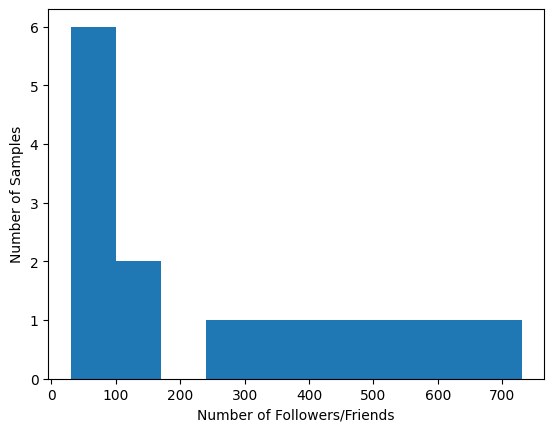

In [24]:
plt.hist(df['Followers'])
plt.xlabel('Number of Followers/Friends')
plt.ylabel('Number of Samples')
plt.show()

Remove the name column using `drop()` method

In [25]:
df = df.drop('name', axis=1)

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [26]:
X = df.drop('Personality', axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [27]:
y = df['Personality'].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12, 2)
(3, 2)
(12,)
(3,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [31]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [32]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

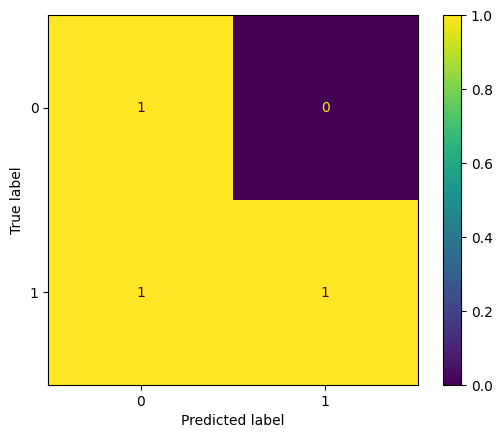

In [33]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Display the accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.6666666666666666


Display the precision

In [35]:
precision = precision_score(y_test, y_pred)
print(precision)

1.0


Display the recall

In [36]:
recall = recall_score(y_test, y_pred)
print(recall)

0.5


Display the f1-score

In [37]:
f1 = f1_score(y_test, y_pred)
print(f1)

0.6666666666666666


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [38]:
my_data = [[300, 150]]
prediction = knn.predict(my_data)

if prediction[0] == 0:
    print("Predicted Personality: Introvert")
else:
    print("Predicted Personality: Extrovert")

Predicted Personality: Introvert
